# 4. Linear SVM: hinge loss and margin regularization

**Question: can a model that emits no probabilities still be operated at a
cost-optimal point?**

The linear SVM is here to make a specific point about the separation between *fitting* a
model and *deciding* with it.

`LinearSVC` produces a signed distance from the separating hyperplane — a margin, not a
probability. The usual workaround is to squash it through a sigmoid and pretend. This
repository does not: the threshold optimiser works directly on the raw margin scale, and
finds the cut point that minimises cost there.

That means the Bayes threshold of 0.0196 from
[notebook 02](02_cost_sensitive_baselines.ipynb) is meaningless for this model. The
operating point has to be learned.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


## Sweeping the margin penalty

`C` controls how hard the hinge loss is penalised for violations. Each configuration is
fitted on the `fit` subset and evaluated on `tune`, with its own cost-optimal margin
threshold.

In [2]:
from scania_aps.costs import optimize_score_threshold
from scania_aps.metrics import evaluate_scores
from scania_aps.models.svm import LinearSVMConfig, build_linear_svm_pipeline
from scania_aps.scoring import positive_class_scores
from scania_aps.split import development_split

split = development_split(train.X, train.y)

rows = []
for C in [0.001, 0.01, 0.1, 1.0]:
    for weight in [None, 20.0, 50.0]:
        config = LinearSVMConfig(C=C, positive_class_weight=weight)
        pipeline = build_linear_svm_pipeline(config).fit(split.X_fit, split.y_fit)
        scores = positive_class_scores(pipeline, split.X_tune)
        chosen = optimize_score_threshold(split.y_tune.to_numpy(), scores.values)
        evaluation = evaluate_scores(
            split.y_tune.to_numpy(),
            scores.values,
            chosen.threshold,
            score_kind=scores.kind,
        )
        rows.append(
            {
                "C": C,
                "class_weight": weight,
                "score_kind": scores.kind,
                "margin_threshold": chosen.threshold,
                "tune_cost": evaluation.total_cost,
                "false_negatives": evaluation.false_negatives,
                "false_positives": evaluation.false_positives,
                "recall": evaluation.recall,
            }
        )

svm_results = pd.DataFrame(rows).sort_values("tune_cost")
print(f"scores are on the '{svm_results['score_kind'].iloc[0]}' scale, not probabilities")
svm_results

C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


scores are on the 'decision' scale, not probabilities


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,C,class_weight,score_kind,margin_threshold,tune_cost,false_negatives,false_positives,recall
0,0.001,NaN,decision,-0.843243,5830.0,6,283,0.960000
3,0.010,NaN,decision,-0.843020,6860.0,9,236,0.940000
1,0.001,20.0,decision,-0.170557,7150.0,10,215,0.933333
2,0.001,50.0,decision,-0.078559,7930.0,10,293,0.933333
4,0.010,20.0,decision,-0.369476,8200.0,10,320,0.933333
6,0.100,NaN,decision,-0.855419,8290.0,12,229,0.920000
5,0.010,50.0,decision,-0.097658,8480.0,11,298,0.926667
10,1.000,20.0,decision,-0.263913,9000.0,13,250,0.913333
7,0.100,20.0,decision,-0.276272,9080.0,13,258,0.913333
9,1.000,NaN,decision,-0.887023,9170.0,13,267,0.913333


Note the `margin_threshold` column: the values are not in `[0, 1]` and are not
probabilities. They are positions on the decision function's own scale, and several are
negative — the cost-optimal rule flags trucks that a default `decision_function > 0`
rule would have called healthy. That is the 50:1 ratio expressing itself.

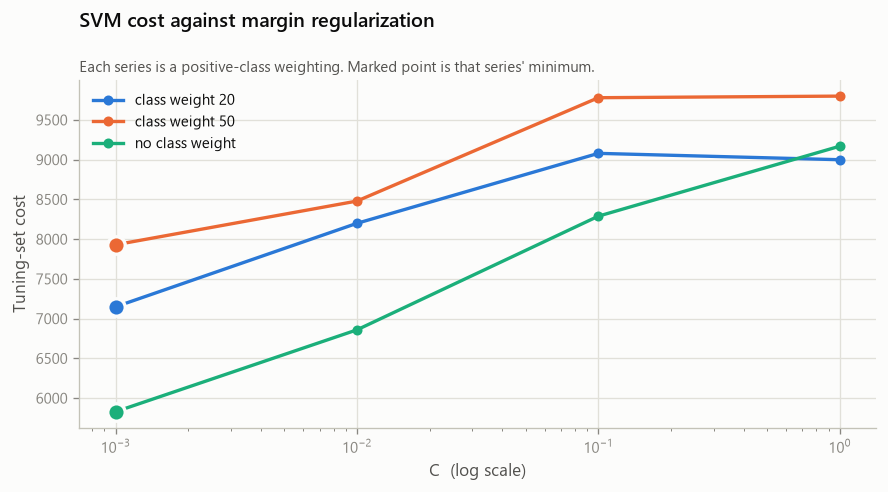

In [3]:
from scania_aps.plotting import series_lines

pivot = svm_results.pivot_table(index="C", columns="class_weight", values="tune_cost", dropna=False)
series = {
    ("no class weight" if pd.isna(col) else f"class weight {col:.0f}"): pivot[col].to_numpy(
        dtype=float
    )
    for col in pivot.columns
}

fig, ax = series_lines(
    pivot.index.to_numpy(dtype=float),
    series,
    title="SVM cost against margin regularization",
    subtitle="Each series is a positive-class weighting. Marked point is that series' minimum.",
    xlabel="C  (log scale)",
    ylabel="Tuning-set cost",
    log_x=True,
    mark_minimum=True,
)

## Where the cost-optimal cut actually falls

The chart below shows cost as a function of the margin threshold for the winning
configuration. The optimiser searches this curve exactly — it evaluates every distinct
score as a candidate cut point rather than sampling a grid.

Text(0.5, 0, 'Margin (decision function value)')

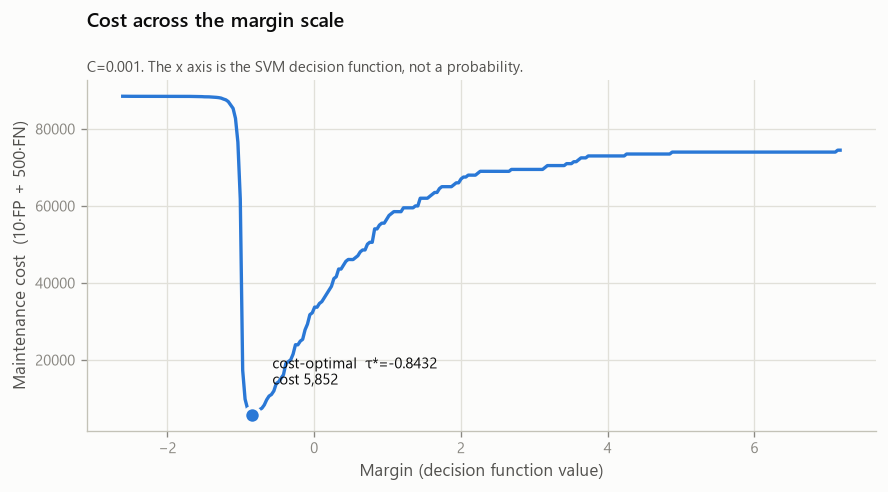

In [4]:
from scania_aps.costs import maintenance_cost
from scania_aps.plotting import cost_curve

best_row = svm_results.iloc[0]
best_config = LinearSVMConfig(
    C=float(best_row["C"]),
    positive_class_weight=(
        None if pd.isna(best_row["class_weight"]) else float(best_row["class_weight"])
    ),
)
best_svm = build_linear_svm_pipeline(best_config).fit(split.X_fit, split.y_fit)
tune_scores = positive_class_scores(best_svm, split.X_tune).values
y_tune = split.y_tune.to_numpy()


grid = np.linspace(tune_scores.min(), tune_scores.max(), 300)
costs = np.array(
    [maintenance_cost(y_tune, (tune_scores >= cut).astype(int)).total_cost for cut in grid]
)

fig, ax = cost_curve(
    grid,
    costs,
    optimal_threshold=float(best_row["margin_threshold"]),
    title="Cost across the margin scale",
    subtitle=f"C={best_config.C:g}. The x axis is the SVM decision function, not a probability.",
)
ax.set_xlabel("Margin (decision function value)")

### Reading the result

The curve is asymmetric, and steeply so on the left. Moving the cut slightly too far
towards "healthy" starts missing failures at 500 apiece, while moving it too far the
other way only adds inspections at 10 apiece. The optimiser lands well down the left
slope for exactly that reason.

This is the same shape seen for probability models in
[notebook 10](10_threshold_optimization.ipynb) — the asymmetry comes from the cost
function, not from the model.

**Next:** [05 — tree ensembles](05_tree_ensembles.ipynb).